In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
import pandas as pd

chemin_fichier = "/home/onyxia/work/binance_data_10_09/BTCUSDT.csv.gz"

df_quotes = pd.read_csv(chemin_fichier)

# conversion in Datetime (unit = microsecondes)
df_quotes['datetime'] = pd.to_datetime(df_quotes['timestamp'], unit='us')

# mid-price
df_quotes['mid_price'] = (df_quotes['ask_price'] + df_quotes['bid_price']) / 2

# We only keep when prices actually move
df_jump_price = df_quotes[df_quotes['mid_price'] != df_quotes['mid_price'].shift(1)]

print(f"Total number of updates of the order book : {len(df_quotes)}")
print(f"Total number of updates in mid-prices : {len(df_jump_price)}")

Total number of updates of the order book : 600685
Total number of updates in mid-prices : 30404


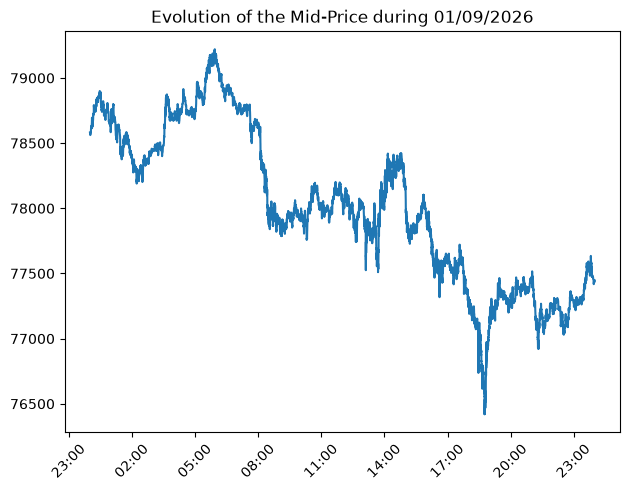

In [3]:
plt.plot(df_jump_price['datetime'], df_jump_price['mid_price'])

ax = plt.gca() #Get current axes

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) #We only keep hours and minutes for the plot
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) #every 3 hours

plt.xticks(rotation=45)
plt.tight_layout()

plt.title("Evolution of the Mid-Price during 01/09/2026")
plt.show()

In [ ]:
time_stamp=CHP()

In [ ]:
#The complexity should be O(len(time_stamp)) thanks to recursion

def neg_log_likelihood(theta,time_stamp):
    alpha0,beta,gamma=theta

    if alpha0<=0 or beta<=0 or gamma<=0 :
        raise ValueError("Be aware, parameters need to be strictly positive")

    if gamma/beta >=1:
        raise ValueError("Be aware, it is necessary that gamma/beta<1")


    k=len(time_stamp)
    A=[]*len(time_stamp)
    A[0]=0

    first_sum=np.log(alpha0+gamma*A[0])

    # First sum
    for i in range(1,k):
        A[i]=(1+A[i-1])*np.exp(-beta*(time_stamp[i]-time_stamp[i-1]))
        first_sum+=np.log(alpha0+gamma*A[i])
    
    # Second sum

    last_time=time_stamp[k-1]   

    second_sum = np.sum((gamma / beta) * (np.exp(-beta * (last_time - time_stamp)) - 1)) #time_stamp is a vector, so everything inside np.sum is a vector


    return -(first_sum - alpha0*last_time + second_sum)